# Exploración Base de datos Secuestros 2025 - Antioquia, La Guajira, Cundinamarca

In [1]:
# Importar dependencias

import pandas as pd
import numpy as np

## Secuestros - dataset

In [3]:
# Traer los datos desdde la API de datos abiertos

df = pd.read_json('https://www.datos.gov.co/resource/d7zw-hpf4.json?$limit=1000000&', dtype={'cod_muni': str})

In [4]:
df.head()

,fecha_hecho,cod_depto,departamento,cod_muni,municipio,tipo_delito,cantidad
0,1996-01-01T00:00:00.000,5,ANTIOQUIA,05042,SANTAFE DE ANTIOQUIA,SECUESTRO SIMPLE,1
1,1996-01-01T00:00:00.000,25,CUNDINAMARCA,25290,FUSAGASUGA,SECUESTRO EXTORSIVO,1
2,1996-01-02T00:00:00.000,5,ANTIOQUIA,05038,ANGOSTURA,SECUESTRO EXTORSIVO,1
3,1996-01-02T00:00:00.000,68,SANTANDER,68001,BUCARAMANGA,SECUESTRO EXTORSIVO,1
4,1996-01-02T00:00:00.000,5,ANTIOQUIA,05088,BELLO,SECUESTRO EXTORSIVO,1


In [4]:
# Generamos un informe preliminar del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28020 entries, 0 to 28019
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   fecha_hecho   28020 non-null  object
 1   cod_depto     28020 non-null  int64 
 2   departamento  28020 non-null  object
 3   cod_muni      28020 non-null  int64 
 4   municipio     28020 non-null  object
 5   tipo_delito   28020 non-null  object
 6   cantidad      28020 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 1.5+ MB


In [22]:
# Convertir la columna 'fecha_hecho' a tipo datetime

df['fecha_hecho_2'] = pd.to_datetime(df['fecha_hecho'])

df['anio'] = pd.to_datetime(df['fecha_hecho']).dt.year
df['mes'] = pd.to_datetime(df['fecha_hecho']).dt.month
df['dia'] = pd.to_datetime(df['fecha_hecho']).dt.day

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28020 entries, 0 to 28019
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   fecha_hecho    28020 non-null  object        
 1   cod_depto      28020 non-null  int64         
 2   departamento   28020 non-null  object        
 3   cod_muni       28020 non-null  object        
 4   municipio      28020 non-null  object        
 5   tipo_delito    28020 non-null  object        
 6   cantidad       28020 non-null  int64         
 7   fecha_hecho_2  28020 non-null  datetime64[ns]
 8   anio           28020 non-null  int32         
 9   mes            28020 non-null  int32         
 10  dia            28020 non-null  int32         
dtypes: datetime64[ns](1), int32(3), int64(2), object(5)
memory usage: 2.0+ MB


In [24]:
df.head()

,fecha_hecho,cod_depto,departamento,cod_muni,municipio,tipo_delito,cantidad,fecha_hecho_2,anio,mes,dia
0,1996-01-01T00:00:00.000,5,ANTIOQUIA,05042,SANTAFE DE ANTIOQUIA,SECUESTRO SIMPLE,1,1996-01-01,1996,1,1
1,1996-01-01T00:00:00.000,25,CUNDINAMARCA,25290,FUSAGASUGA,SECUESTRO EXTORSIVO,1,1996-01-01,1996,1,1
2,1996-01-02T00:00:00.000,5,ANTIOQUIA,05038,ANGOSTURA,SECUESTRO EXTORSIVO,1,1996-01-02,1996,1,2
3,1996-01-02T00:00:00.000,68,SANTANDER,68001,BUCARAMANGA,SECUESTRO EXTORSIVO,1,1996-01-02,1996,1,2
4,1996-01-02T00:00:00.000,5,ANTIOQUIA,05088,BELLO,SECUESTRO EXTORSIVO,1,1996-01-02,1996,1,2


In [5]:
# Obtener un conteo de registros nulos por columna
df.isnull().sum()

fecha_hecho     0
cod_depto       0
departamento    0
cod_muni        0
municipio       0
tipo_delito     0
cantidad        0
dtype: int64

In [6]:
# Resumen estadístico de las columnas numéricas. Arroja: conteo, media, desviación estándar, mínimo, máximo, percentiles 25, 50, 75.
df.describe()

,cod_depto,cod_muni,cantidad
count,28020.000000,28020.000000,28020.000000
mean,38.011278,38309.406995,1.002034
std,27.431869,27415.968503,0.054389
min,5.000000,5001.000000,1.000000
25%,13.000000,13442.000000,1.000000
50%,27.000000,27001.000000,1.000000
75%,68.000000,68001.000000,1.000000
max,99.000000,99773.000000,4.000000


In [7]:
# Resumen estadístico de las columnas categóricas. Arroja: conteo, N° de valores únicos, valor que corresponde a la moda y su frecuencia
df.describe(include = ['O'])

,fecha_hecho,departamento,municipio,tipo_delito
count,28020,28020,28020,28020
unique,6638,33,909,2
top,1999-05-30T00:00:00.000,ANTIOQUIA,BOGOTA D.C.,SECUESTRO EXTORSIVO
freq,161,4697,1553,17872


In [8]:
# N° Valores únicos por columna SIN tener en cuenta nulos
df.nunique()

fecha_hecho     6638
cod_depto         33
departamento      33
cod_muni         974
municipio        909
tipo_delito        2
cantidad           4
dtype: int64

In [10]:
# Conteo agrupado por municipios
df_municipios = df.groupby(["departamento", "cod_muni", "municipio"])['municipio'].count().reset_index(name='total')

In [11]:
df_municipios

,departamento,cod_muni,municipio,total
0,AMAZONAS,91001,LETICIA,3
1,ANTIOQUIA,5001,MEDELLIN,888
2,ANTIOQUIA,5002,ABEJORRAL,48
3,ANTIOQUIA,5004,ABRIAQUI,22
4,ANTIOQUIA,5021,ALEJANDRIA,9
...,...,...,...,...
974,VAUPES,97666,TARAIRA,1
975,VICHADA,99001,PUERTO CARREÑO,7
976,VICHADA,99524,LA PRIMAVERA,25
977,VICHADA,99624,SANTA ROSALIA,1


In [12]:
#importamos las librerías usadas para los gráficos.

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt


#Esto es simplemente para cambiar el tamaño de las etiquetas, pero no es necesario hacerlo
# se pueden consultar los estilos buscando: matplotlib.org styles
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['xtick.labelsize'] = 12

plt.style.use("fivethirtyeight")
#Esta línea es para cambiar los colores que vienen por defecto
sns.set_palette('Accent')

KeyboardInterrupt: 

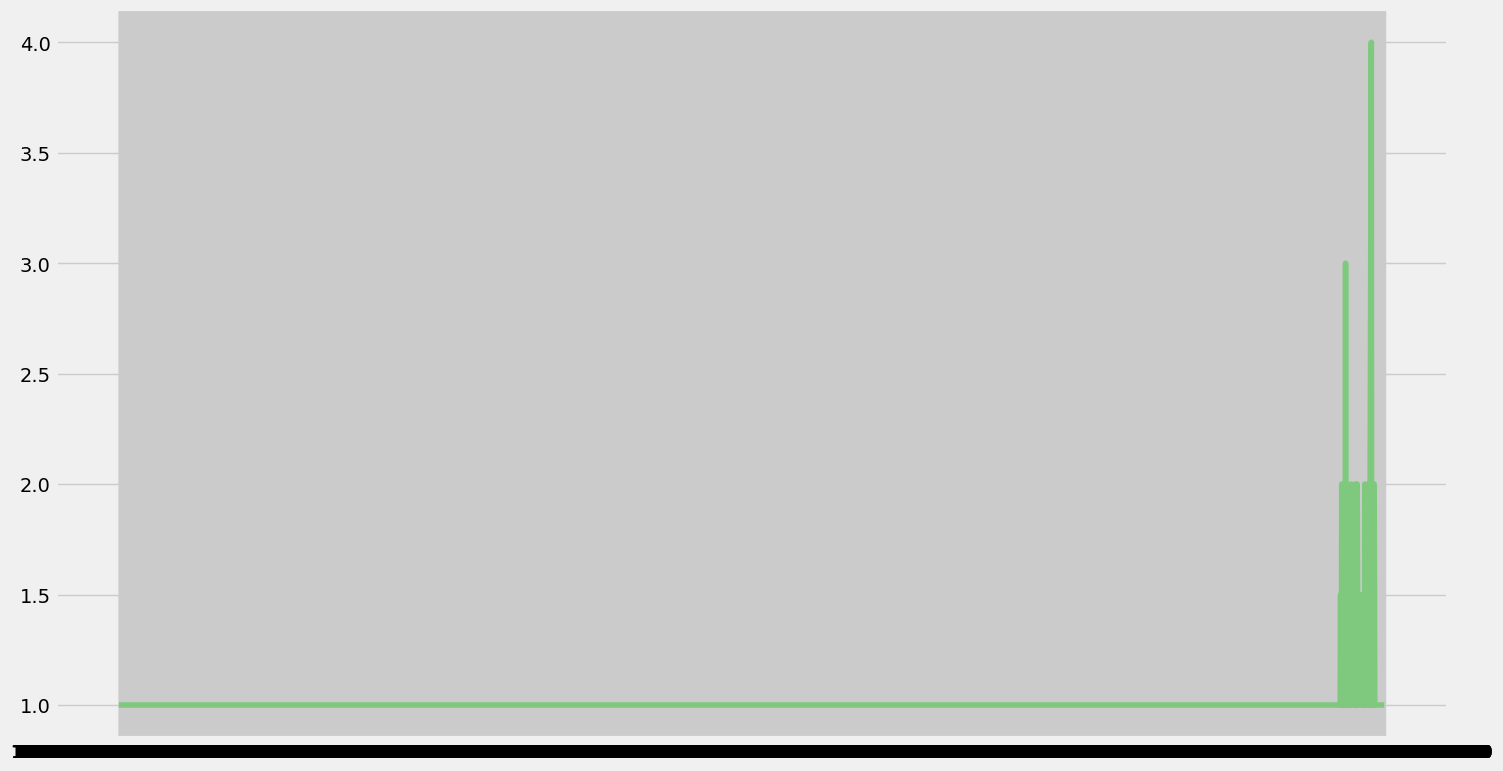

In [15]:
# Serie de tiempo por tipo de secuestros

plt.figure(figsize=(16,9))
ax = sns.lineplot(
    data=df,
    x='fecha_hecho',
    y='cantidad',
    hue='tipo_delito'
)

ax.set_title('Series de Tiempo por tipo de secuestro')
plt.xticks(rotation=45,ha='right')
plt.show()

## Población DANE - serie Proyecciones y retroproyecciones
Datos de población obtenidos de proyecciones y retroproyecciones realizadas a partir de operaciones estadísticas censales por el DANE.

In [5]:
%pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]

Note: you may need to restart the kernel to use updated packages.


In [2]:
import openpyxl

In [27]:
# Archivo con datos de población por municipio entre 1995 y 2004:

poblacion_1995_2004 = pd.read_excel('../Datos/DCD-area-proypoblacion-Mun-1995-2004.xlsx', dtype={'DP': str, 'MPIO': str})
poblacion_1995_2004.head()

,DP,DPNOM,MPIO,DPMP,AÑO,ÁREA GEOGRÁFICA,Población
0,05,Antioquia,05001,Medellín,1995,Cabecera Municipal,1704227
1,05,Antioquia,05001,Medellín,1995,Centros Poblados y Rural Disperso,52534
2,05,Antioquia,05001,Medellín,1995,Total,1756761
3,05,Antioquia,05001,Medellín,1996,Cabecera Municipal,1735720
4,05,Antioquia,05001,Medellín,1996,Centros Poblados y Rural Disperso,52111


In [28]:
# Archivo con datos de población por municipio entre 2005 y 2019:

poblacion_2005_2019 = pd.read_excel('../Datos/DCD-area-proypoblacion-Mun-2005-2019.xlsx',  dtype={'DP': str, 'MPIO': str})
poblacion_2005_2019.head()

,DP,DPNOM,DPMP,MPIO,AÑO,ÁREA GEOGRÁFICA,Población
0,05,Antioquia,Medellín,05001,2005,Cabecera Municipal,1997763
1,05,Antioquia,Medellín,05001,2005,Centros Poblados y Rural Disperso,48578
2,05,Antioquia,Medellín,05001,2005,Total,2046341
3,05,Antioquia,Abejorral,05002,2005,Cabecera Municipal,7158
4,05,Antioquia,Abejorral,05002,2005,Centros Poblados y Rural Disperso,15784


In [29]:
# Archivo con datos de población por municipio entre 2020 y 2035:

poblacion_2020_2035 = pd.read_excel('../Datos/DCD-area-proypoblacion-Mun-2020-2035-ActPostCOVID-19.xlsx',  dtype={'DP': str, 'MPIO': str})
poblacion_2020_2035.head()

,DP,DPNOM,MPIO,DPMP,AÑO,ÁREA GEOGRÁFICA,Población
0,05,Antioquia,05001,Medellín,2020,Cabecera Municipal,2476569
1,05,Antioquia,05001,Medellín,2020,Centros Poblados y Rural Disperso,43023
2,05,Antioquia,05001,Medellín,2020,Total,2519592
3,05,Antioquia,05001,Medellín,2021,Cabecera Municipal,2506656
4,05,Antioquia,05001,Medellín,2021,Centros Poblados y Rural Disperso,42352


In [30]:
# Unir los tres dataframes de población usando pd.concat (concatena filas)
poblacion_total = pd.concat([poblacion_1995_2004, poblacion_2005_2019, poblacion_2020_2035], ignore_index=True)
poblacion_total.head()

,DP,DPNOM,MPIO,DPMP,AÑO,ÁREA GEOGRÁFICA,Población
0,05,Antioquia,05001,Medellín,1995,Cabecera Municipal,1704227
1,05,Antioquia,05001,Medellín,1995,Centros Poblados y Rural Disperso,52534
2,05,Antioquia,05001,Medellín,1995,Total,1756761
3,05,Antioquia,05001,Medellín,1996,Cabecera Municipal,1735720
4,05,Antioquia,05001,Medellín,1996,Centros Poblados y Rural Disperso,52111


In [31]:
# conservar solo las filas donde la columna "ÁREA GEOGRÁFICA" sea igual a "Total"

poblacion_total = poblacion_total[poblacion_total['ÁREA GEOGRÁFICA'] == 'Total']
poblacion_total.head()

,DP,DPNOM,MPIO,DPMP,AÑO,ÁREA GEOGRÁFICA,Población
2,05,Antioquia,05001,Medellín,1995,Total,1756761
5,05,Antioquia,05001,Medellín,1996,Total,1787831
8,05,Antioquia,05001,Medellín,1997,Total,1816301
11,05,Antioquia,05001,Medellín,1998,Total,1847391
14,05,Antioquia,05001,Medellín,1999,Total,1877865


In [32]:
poblacion_total['AÑO'].unique()

array([1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005,
       2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016,
       2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027,
       2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035])

In [22]:
poblacion_total.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46002 entries, 2 to 138005
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   DP               46002 non-null  object
 1   DPNOM            46002 non-null  object
 2   MPIO             46002 non-null  object
 3   DPMP             46002 non-null  object
 4   AÑO              46002 non-null  int64 
 5   ÁREA GEOGRÁFICA  46002 non-null  object
 6   Población        46002 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 2.8+ MB


## Minería ilegal - dataset

1. Buscar el enlace del dataset en la página de datos abiertos.
    * https://www.datos.gov.co/Seguridad-y-Defensa/CAPTURAS-POR-MINER-A-ILEGAL/3wcs-8xp9/data_preview
    * Fuente: Ministerio de Defensa
2. Generar código de conexión a la API de datos abiertos
    * botón acciones > API > copiar al portapapeles
    * Agregando a la url el complemento "?$limit=1000000&", se puede exceder el límite predeterminado de 1000 registros de la API
3. Traer dataset con -pd.read_json-
    * Forzar el tipo string para las variables de código de departamento y municipio (DIVIPOLA)

In [5]:
capturas_mineria_ilegal = pd.read_json('https://www.datos.gov.co/resource/3wcs-8xp9.json?$limit=1000000&', dtype={'cod_depto': str, 'cod_muni': str})

capturas_mineria_ilegal.head()

,fecha_hecho,cod_depto,departamento,cod_muni,municipio,cantidad,unidad_de_medida
0,2010-08-09T00:00:00.000,23,CORDOBA,23068,AYAPEL,7,PERSONA
1,2010-08-11T00:00:00.000,54,NORTE DE SANTANDER,54377,LABATECA,8,PERSONA
2,2010-08-12T00:00:00.000,25,CUNDINAMARCA,25612,RICAURTE,11,PERSONA
3,2010-08-19T00:00:00.000,23,CORDOBA,23068,AYAPEL,10,PERSONA
4,2010-08-19T00:00:00.000,44,LA GUAJIRA,44430,MAICAO,5,PERSONA


**Temporalidad de los datos**

Se tienen datos entre enero de 2010 y abril de 2025.

In [6]:
capturas_mineria_ilegal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6667 entries, 0 to 6666
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   fecha_hecho       6667 non-null   object
 1   cod_depto         6667 non-null   object
 2   departamento      6667 non-null   object
 3   cod_muni          6667 non-null   object
 4   municipio         6667 non-null   object
 5   cantidad          6667 non-null   int64 
 6   unidad_de_medida  6667 non-null   object
dtypes: int64(1), object(6)
memory usage: 364.7+ KB


In [19]:
# Convertir la columna 'fecha_hecho' a tipo datetime

capturas_mineria_ilegal['fecha_hecho_2'] = pd.to_datetime(capturas_mineria_ilegal['fecha_hecho'])

capturas_mineria_ilegal['anio'] = pd.to_datetime(capturas_mineria_ilegal['fecha_hecho']).dt.year
capturas_mineria_ilegal['mes'] = pd.to_datetime(capturas_mineria_ilegal['fecha_hecho']).dt.month
capturas_mineria_ilegal['dia'] = pd.to_datetime(capturas_mineria_ilegal['fecha_hecho']).dt.day

In [20]:
capturas_mineria_ilegal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6667 entries, 0 to 6666
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   fecha_hecho       6667 non-null   object        
 1   cod_depto         6667 non-null   object        
 2   departamento      6667 non-null   object        
 3   cod_muni          6667 non-null   object        
 4   municipio         6667 non-null   object        
 5   cantidad          6667 non-null   int64         
 6   unidad_de_medida  6667 non-null   object        
 7   fecha_hecho_2     6667 non-null   datetime64[ns]
 8   anio              6667 non-null   int32         
 9   mes               6667 non-null   int32         
 10  dia               6667 non-null   int32         
dtypes: datetime64[ns](1), int32(3), int64(1), object(6)
memory usage: 494.9+ KB


In [21]:
capturas_mineria_ilegal.head()

,fecha_hecho,cod_depto,departamento,cod_muni,municipio,cantidad,unidad_de_medida,fecha_hecho_2,anio,mes,dia
0,2010-08-09T00:00:00.000,23,CORDOBA,23068,AYAPEL,7,PERSONA,2010-08-09,2010,8,9
1,2010-08-11T00:00:00.000,54,NORTE DE SANTANDER,54377,LABATECA,8,PERSONA,2010-08-11,2010,8,11
2,2010-08-12T00:00:00.000,25,CUNDINAMARCA,25612,RICAURTE,11,PERSONA,2010-08-12,2010,8,12
3,2010-08-19T00:00:00.000,23,CORDOBA,23068,AYAPEL,10,PERSONA,2010-08-19,2010,8,19
4,2010-08-19T00:00:00.000,44,LA GUAJIRA,44430,MAICAO,5,PERSONA,2010-08-19,2010,8,19


## Extorsión - dataset

1. Buscar el enlace del dataset en la página de datos abiertos.
    * https://www.datos.gov.co/Seguridad-y-Defensa/EXTORSION/q2ib-t9am/data_preview
    * Fuente: Ministerio de Defensa
2. Generar código de conexión a la API de datos abiertos
    * botón acciones > API > copiar al portapapeles
    * Agregando a la url el complemento "?$limit=1000000&", se puede exceder el límite predeterminado de 1000 registros de la API
3. Traer dataset con -pd.read_json-
    * Forzar el tipo string para las variables de código de departamento y municipio (DIVIPOLA)

In [7]:
victimas_extorsion = pd.read_json('https://www.datos.gov.co/resource/q2ib-t9am.json?$limit=1000000&', dtype={'cod_depto': str, 'cod_muni': str})

victimas_extorsion.head()

,fecha_hecho,cod_depto,departamento,cod_muni,municipio,cantidad
0,1996-01-01T00:00:00.000,50,META,50689,SAN MARTIN,1
1,1996-01-01T00:00:00.000,11,BOGOTA D.C.,11001,BOGOTA D.C.,1
2,1996-01-02T00:00:00.000,11,BOGOTA D.C.,11001,BOGOTA D.C.,2
3,1996-01-02T00:00:00.000,54,NORTE DE SANTANDER,54001,CUCUTA,1
4,1996-01-03T00:00:00.000,20,CESAR,20001,VALLEDUPAR,1


In [8]:
victimas_extorsion.tail()

,fecha_hecho,cod_depto,departamento,cod_muni,municipio,cantidad
94010,2025-04-30T00:00:00.000,20,CESAR,20001,VALLEDUPAR,1
94011,2025-04-30T00:00:00.000,44,LA GUAJIRA,44847,URIBIA,1
94012,2025-04-30T00:00:00.000,47,MAGDALENA,47001,SANTA MARTA,1
94013,2025-04-30T00:00:00.000,66,RISARALDA,66572,PUEBLO RICO,1
94014,2025-04-30T00:00:00.000,76,VALLE DEL CAUCA,76520,PALMIRA,1


**Temporalidad de los datos**

Se tienen datos entre enero de 1996 y abril de 2025.

In [9]:
victimas_extorsion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94015 entries, 0 to 94014
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   fecha_hecho   94015 non-null  object
 1   cod_depto     94015 non-null  object
 2   departamento  94015 non-null  object
 3   cod_muni      94015 non-null  object
 4   municipio     94015 non-null  object
 5   cantidad      94015 non-null  int64 
dtypes: int64(1), object(5)
memory usage: 4.3+ MB


In [16]:
# Convertir la columna 'fecha_hecho' a tipo datetime

victimas_extorsion['fecha_hecho_2'] = pd.to_datetime(victimas_extorsion['fecha_hecho'])

victimas_extorsion['anio'] = pd.to_datetime(victimas_extorsion['fecha_hecho']).dt.year
victimas_extorsion['mes'] = pd.to_datetime(victimas_extorsion['fecha_hecho']).dt.month
victimas_extorsion['dia'] = pd.to_datetime(victimas_extorsion['fecha_hecho']).dt.day

In [17]:
victimas_extorsion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94015 entries, 0 to 94014
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   fecha_hecho    94015 non-null  object        
 1   cod_depto      94015 non-null  object        
 2   departamento   94015 non-null  object        
 3   cod_muni       94015 non-null  object        
 4   municipio      94015 non-null  object        
 5   cantidad       94015 non-null  int64         
 6   fecha_hecho_2  94015 non-null  datetime64[ns]
 7   fecha_hecho_3  94015 non-null  datetime64[ns]
 8   anio           94015 non-null  int32         
 9   mes            94015 non-null  int32         
 10  dia            94015 non-null  int32         
dtypes: datetime64[ns](2), int32(3), int64(1), object(5)
memory usage: 6.8+ MB


In [18]:
victimas_extorsion.head()

,fecha_hecho,cod_depto,departamento,cod_muni,municipio,cantidad,fecha_hecho_2,fecha_hecho_3,anio,mes,dia
0,1996-01-01T00:00:00.000,50,META,50689,SAN MARTIN,1,1996-01-01,1996-01-01,1996,1,1
1,1996-01-01T00:00:00.000,11,BOGOTA D.C.,11001,BOGOTA D.C.,1,1996-01-01,1996-01-01,1996,1,1
2,1996-01-02T00:00:00.000,11,BOGOTA D.C.,11001,BOGOTA D.C.,2,1996-01-02,1996-01-02,1996,1,2
3,1996-01-02T00:00:00.000,54,NORTE DE SANTANDER,54001,CUCUTA,1,1996-01-02,1996-01-02,1996,1,2
4,1996-01-03T00:00:00.000,20,CESAR,20001,VALLEDUPAR,1,1996-01-03,1996-01-03,1996,1,3


## Dataset unido

Se aplican operaciones -merge- para unir los datasets investigados al dataset de secuestros.

In [ ]:
# Reducir dataframe de población total con variables llave y variable numérica de interés

poblacion_total_reducido = poblacion_total[['MPIO', 'AÑO', 'Población']]
poblacion_total_reducido.head()

,MPIO,AÑO,Población
2,05001,1995,1756761
5,05001,1996,1787831
8,05001,1997,1816301
11,05001,1998,1847391
14,05001,1999,1877865


In [37]:
# Unir los dataframes de secuestros y población total

df_unido = pd.merge(df, poblacion_total_reducido, left_on=['cod_muni', 'anio'], right_on=['MPIO', 'AÑO'], how='left')
df_unido.head()

,fecha_hecho,cod_depto,departamento,cod_muni,municipio,tipo_delito,cantidad,fecha_hecho_2,anio,mes,dia,MPIO,AÑO,Población
0,1996-01-01T00:00:00.000,5,ANTIOQUIA,05042,SANTAFE DE ANTIOQUIA,SECUESTRO SIMPLE,1,1996-01-01,1996,1,1,05042,1996,21787
1,1996-01-01T00:00:00.000,25,CUNDINAMARCA,25290,FUSAGASUGA,SECUESTRO EXTORSIVO,1,1996-01-01,1996,1,1,25290,1996,77123
2,1996-01-02T00:00:00.000,5,ANTIOQUIA,05038,ANGOSTURA,SECUESTRO EXTORSIVO,1,1996-01-02,1996,1,2,05038,1996,12845
3,1996-01-02T00:00:00.000,68,SANTANDER,68001,BUCARAMANGA,SECUESTRO EXTORSIVO,1,1996-01-02,1996,1,2,68001,1996,413058
4,1996-01-02T00:00:00.000,5,ANTIOQUIA,05088,BELLO,SECUESTRO EXTORSIVO,1,1996-01-02,1996,1,2,05088,1996,315434


In [36]:
# Reducir dataframe de capturas por mineria ilegal con variables llave y variable numérica de interés

capturas_mineria_ilegal_reducido = capturas_mineria_ilegal[['cod_muni', 'fecha_hecho_2', 'cantidad']]
capturas_mineria_ilegal_reducido.head()

,cod_muni,fecha_hecho_2,cantidad
0,23068,2010-08-09,7
1,54377,2010-08-11,8
2,25612,2010-08-12,11
3,23068,2010-08-19,10
4,44430,2010-08-19,5


In [ ]:
# Unir los dataframes de secuestros y capturas por mineria ilegal

df_unido = pd.merge(df_unido, capturas_mineria_ilegal_reducido, left_on=['cod_muni', 'fecha_hecho_2'], right_on=['cod_muni', 'fecha_hecho_2'], how='left')
df_unido.tail()

,fecha_hecho,cod_depto,departamento,cod_muni,municipio,tipo_delito,cantidad_x,fecha_hecho_2,anio,mes,dia,MPIO,AÑO,Población,cantidad_y,cantidad
28015,2025-04-16T00:00:00.000,5,ANTIOQUIA,05440,MARINILLA,SECUESTRO EXTORSIVO,1,2025-04-16,2025,4,16,05440,2025,70392,NaN,NaN
28016,2025-04-16T00:00:00.000,5,ANTIOQUIA,05440,MARINILLA,SECUESTRO EXTORSIVO,1,2025-04-16,2025,4,16,05440,2025,70392,NaN,NaN
28017,2025-04-16T00:00:00.000,19,CAUCA,19001,POPAYAN,SECUESTRO EXTORSIVO,1,2025-04-16,2025,4,16,19001,2025,346403,NaN,NaN
28018,2025-04-16T00:00:00.000,19,CAUCA,19001,POPAYAN,SECUESTRO EXTORSIVO,1,2025-04-16,2025,4,16,19001,2025,346403,NaN,NaN
28019,2025-04-21T00:00:00.000,5,ANTIOQUIA,05001,MEDELLIN,SECUESTRO EXTORSIVO,1,2025-04-21,2025,4,21,05001,2025,2634570,NaN,NaN


In [42]:
# Reducir dataframe de víctimas de extorsión con variables llave y variable numérica de interés

victimas_extorsion_reducido = victimas_extorsion[['cod_muni', 'fecha_hecho_2', 'cantidad']]
victimas_extorsion_reducido = victimas_extorsion_reducido.rename(columns = {'cantidad': 'num_victimas_extorsion'})
victimas_extorsion_reducido.head()

,cod_muni,fecha_hecho_2,num_victimas_extorsion
0,50689,1996-01-01,1
1,11001,1996-01-01,1
2,11001,1996-01-02,2
3,54001,1996-01-02,1
4,20001,1996-01-03,1


In [43]:
# Unir los dataframes de secuestros y capturas por mineria ilegal

df_unido = pd.merge(df_unido, victimas_extorsion_reducido, left_on=['cod_muni', 'fecha_hecho_2'], right_on=['cod_muni', 'fecha_hecho_2'], how='left')
df_unido.tail()

,fecha_hecho,cod_depto,departamento,cod_muni,municipio,tipo_delito,cantidad_x,fecha_hecho_2,anio,mes,dia,MPIO,AÑO,Población,cantidad_y,cantidad,num_victimas_extorsion
28104,2025-04-16T00:00:00.000,5,ANTIOQUIA,05440,MARINILLA,SECUESTRO EXTORSIVO,1,2025-04-16,2025,4,16,05440,2025,70392,NaN,NaN,NaN
28105,2025-04-16T00:00:00.000,19,CAUCA,19001,POPAYAN,SECUESTRO EXTORSIVO,1,2025-04-16,2025,4,16,19001,2025,346403,NaN,NaN,NaN
28106,2025-04-16T00:00:00.000,19,CAUCA,19001,POPAYAN,SECUESTRO EXTORSIVO,1,2025-04-16,2025,4,16,19001,2025,346403,NaN,NaN,NaN
28107,2025-04-21T00:00:00.000,5,ANTIOQUIA,05001,MEDELLIN,SECUESTRO EXTORSIVO,1,2025-04-21,2025,4,21,05001,2025,2634570,NaN,NaN,1.0
28108,2025-04-21T00:00:00.000,5,ANTIOQUIA,05001,MEDELLIN,SECUESTRO EXTORSIVO,1,2025-04-21,2025,4,21,05001,2025,2634570,NaN,NaN,1.0
